# Week 10 — Attention, transformers & graph networks for EM

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg
**Author:** Prof. Dr. Philipp Pelz
**Prerequisites:** Week 4 (honest validation) · Week 6 (MLPs, backprop, PyTorch) · Week 7 (CNNs, saliency/occlusion)
**Time budget:** ~90 minutes for a beginner working steadily · whole notebook runs on a CPU in < 5 min

## What you will do

1. **Part 1 — Self-attention from scratch (NumPy).** Implement $\mathrm{softmax}(QK^\top/\sqrt{d_k})V$,
   reproduce the hand-traced 4-token example from the lecture, verify **permutation equivariance**, and see why
   the $\sqrt{d_k}$ scaling matters.
2. **Part 2 — A mini Vision Transformer on synthetic diffraction patterns (PyTorch).** Classify
   square / hexagonal / rectangular lattices from randomly rotated, noisy spot patterns; ablate the
   **positional embedding**; test at a **lower dose**; compare **attention maps with occlusion**.
3. **Part 3 — (optional) Message passing by hand.** Turn atom-column lattices into graphs, write a
   message-passing layer with `index_add_` (no `torch_geometric`), and show that neighbour information is
   exactly what a per-column model is missing.

> The code and seeds match the figures in the Week 10 slides, so your numbers should be close to the
> lecture's (0.99 / 0.90 / 0.42 for the ViT; 0.55 / 0.99 / 1.00 for the GNN). Small differences across
> PyTorch versions and CPUs are normal.

In [1]:
# --- Cell 1: Imports ---
# On Colab everything below is pre-installed; locally use the course environment.
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)          # small models: a few threads are faster than many
T_START = time.time()
print("NumPy", np.__version__, "| PyTorch", torch.__version__)

NumPy 1.26.4 | PyTorch 2.7.1+cu126


## Part 1 — Self-attention from scratch

Given tokens stacked as rows of $X\in\mathbb{R}^{L\times d}$ and projections $W_Q, W_K, W_V$:

$$Q = XW_Q,\quad K = XW_K,\quad V = XW_V,\qquad
\mathrm{Attention}(Q,K,V) = \underbrace{\mathrm{softmax}\!\Big(\tfrac{QK^\top}{\sqrt{d_k}}\Big)}_{A\in\mathbb{R}^{L\times L}} V .$$

Each row of $A$ sums to 1: row $i$ says how much token $i$ draws from every token $j$.
The softmax is applied **row-wise**. We subtract the row maximum before exponentiating for numerical stability
(this does not change the result — why?).

In [2]:
# --- Cell 2: softmax and scaled dot-product attention in NumPy ---

def softmax(S, axis=-1):
    S = S - S.max(axis=axis, keepdims=True)      # numerical stability
    E = np.exp(S)
    return E / E.sum(axis=axis, keepdims=True)


def attention(Q, K, V, scale=True):
    # Q: (L, d_k), K: (L, d_k), V: (L, d_v)  ->  Z: (L, d_v), A: (L, L)
    d_k = Q.shape[-1]
    S = Q @ K.T
    if scale:
        S = S / np.sqrt(d_k)
    A = softmax(S, axis=-1)
    return A @ V, A


# The hand-traced example from the lecture: tokens A (bright disc), B (weak disc), C (disc pair), D (background)
Q = np.array([[1, 0], [0, 1], [1, 1], [0, 0]], float)
K = np.array([[1, 0], [0, 1], [1, 1], [-1, 0]], float)
V = np.array([[1, 0], [0, 1], [1, 1], [0, 0]], float)

Z, A = attention(Q, K, V)
np.set_printoptions(precision=3, suppress=True)
print("Attention matrix A (rows = queries, cols = keys):\n", A)
print("\nRow sums:", A.sum(1))
print("z_C =", Z[2], "  (lecture: (0.71, 0.71))")
print("Row D (zero query) is uniform:", A[3])

Attention matrix A (rows = queries, cols = keys):
 [[0.365 0.18  0.365 0.089]
 [0.165 0.335 0.335 0.165]
 [0.234 0.234 0.475 0.057]
 [0.25  0.25  0.25  0.25 ]]

Row sums: [1. 1. 1. 1.]
z_C = [0.709 0.709]   (lecture: (0.71, 0.71))
Row D (zero query) is uniform: [0.25 0.25 0.25 0.25]


### Permutation equivariance

If we shuffle the tokens with a permutation $P$, then $\mathrm{Attention}(PX) = P\,\mathrm{Attention}(X)$:
the same output vectors come out, only reordered. Attention therefore sees a **set**, not a sequence —
which is why transformers need positional encodings for images and spectra.

In [3]:
# --- Cell 3: verify permutation equivariance with random projections ---
rng = np.random.default_rng(0)
L, d, d_k = 6, 8, 4
X  = rng.normal(size=(L, d))
WQ, WK, WV = (rng.normal(size=(d, d_k)) for _ in range(3))

Z, _ = attention(X @ WQ, X @ WK, X @ WV)
perm = rng.permutation(L)
Zp, _ = attention(X[perm] @ WQ, X[perm] @ WK, X[perm] @ WV)

print("permutation:", perm)
print("max |Attn(PX) - P Attn(X)| =", np.abs(Zp - Z[perm]).max())

permutation: [1 4 0 5 2 3]
max |Attn(PX) - P Attn(X)| = 2.6645352591003757e-15


### Why divide by $\sqrt{d_k}$?

For random $\mathbf q,\mathbf k$ with unit-variance entries, $\mathrm{Var}(\mathbf q^\top\mathbf k)=d_k$.
Large scores push the softmax towards one-hot, where its gradient vanishes. Let's measure how "peaked" the
attention rows are with and without scaling.

findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


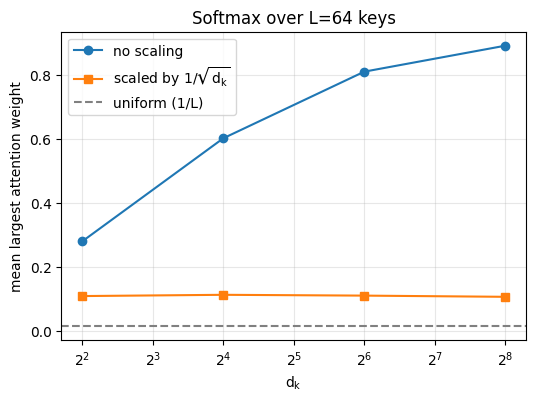

d_k=   4: max weight raw=0.28  scaled=0.11
d_k=  16: max weight raw=0.60  scaled=0.11
d_k=  64: max weight raw=0.81  scaled=0.11
d_k= 256: max weight raw=0.89  scaled=0.11


In [4]:
# --- Cell 4: softmax saturation vs d_k ---
rng = np.random.default_rng(1)
L = 64
dks = [4, 16, 64, 256]
max_raw, max_scaled = [], []
for dk in dks:
    q = rng.normal(size=(500, dk)); k = rng.normal(size=(L, dk))
    max_raw.append(softmax(q @ k.T).max(1).mean())
    max_scaled.append(softmax(q @ k.T / np.sqrt(dk)).max(1).mean())

plt.figure(figsize=(6, 4))
plt.plot(dks, max_raw, "o-", label="no scaling")
plt.plot(dks, max_scaled, "s-", label=r"scaled by $1/\sqrt{d_k}$")
plt.axhline(1 / L, ls="--", c="grey", label="uniform (1/L)")
plt.xscale("log", base=2); plt.xlabel("$d_k$"); plt.ylabel("mean largest attention weight")
plt.title(f"Softmax over L={L} keys"); plt.legend(); plt.grid(alpha=0.3); plt.show()
for dk, a, b in zip(dks, max_raw, max_scaled):
    print(f"d_k={dk:4d}: max weight raw={a:.2f}  scaled={b:.2f}")

## Exercise 1 — Multi-head attention

**Instructions (try before running):** implement `multi_head_attention(X, WQ, WK, WV, WO, H)`:

1. Project: $Q = XW_Q$, $K = XW_K$, $V = XW_V$ (each $L\times d$).
2. Split the last dimension into `H` heads of size $d/H$.
3. Run `attention` on each head separately.
4. Concatenate the head outputs along the feature axis and multiply by $W_O$ ($d\times d$).
5. Check that the result is still permutation-equivariant.

The cell ships a working solution — the `# (try this yourself)` lines are the ones to attempt first.

In [5]:
# --- Cell 5: Exercise cell (working version with try-this markers) ---

def multi_head_attention(X, WQ, WK, WV, WO, H):
    L, d = X.shape
    dh = d // H
    Q, K, V = X @ WQ, X @ WK, X @ WV                       # (try this yourself) step 1
    heads, attn = [], []
    for h in range(H):                                       # (try this yourself) steps 2-3
        sl = slice(h * dh, (h + 1) * dh)
        z, a = attention(Q[:, sl], K[:, sl], V[:, sl])
        heads.append(z); attn.append(a)
    return np.concatenate(heads, axis=1) @ WO, np.stack(attn)   # (try this yourself) step 4


rng = np.random.default_rng(2)
L, d, H = 6, 8, 2
X = rng.normal(size=(L, d))
WQ, WK, WV, WO = (rng.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))
Z, As = multi_head_attention(X, WQ, WK, WV, WO, H)
perm = rng.permutation(L)
Zp, _ = multi_head_attention(X[perm], WQ, WK, WV, WO, H)
print("output shape:", Z.shape, "| attention maps:", As.shape)
print("equivariance error:", np.abs(Zp - Z[perm]).max())    # (try this yourself) step 5

output shape: (6, 8) | attention maps: (2, 6, 6)
equivariance error: 8.881784197001252e-16


### Solution

```python
def multi_head_attention(X, WQ, WK, WV, WO, H):
    L, d = X.shape
    dh = d // H
    Q, K, V = X @ WQ, X @ WK, X @ WV
    # reshape to (H, L, dh) and use batched matmul instead of a loop
    Qh, Kh, Vh = (M.reshape(L, H, dh).transpose(1, 0, 2) for M in (Q, K, V))
    A = softmax(Qh @ Kh.transpose(0, 2, 1) / np.sqrt(dh), axis=-1)   # (H, L, L)
    Z = (A @ Vh).transpose(1, 0, 2).reshape(L, d)
    return Z @ WO, A
```

Each head has its own notion of similarity (its own slice of $W_Q, W_K$); the cost is the same as one
full-width head because each head works in $d/H$ dimensions.

## Part 2 — A mini-ViT on synthetic diffraction patterns

### The data

We simulate 32×32 zone-axis **spot patterns** for three 2-D lattices:

| class | reciprocal lattice |
|---|---|
| square | $|\mathbf a^*| = |\mathbf b^*|$, angle 90° |
| hexagonal | $|\mathbf a^*| = |\mathbf b^*|$, angle 60° |
| rectangular | $|\mathbf b^*| = (1.3\text{–}1.6)\,|\mathbf a^*|$, angle 90° |

Every pattern has a **random in-plane rotation**, a random lattice scale, random spot intensities
(a crude stand-in for excitation errors) with **Friedel symmetry** $I(\mathbf g)=I(-\mathbf g)$,
a bright central beam and **Poisson noise**. The input is $\log(1+\text{counts})$, normalised to $[0,1]$.

Because of the random rotation and scale, the class is only encoded in **angles and length ratios between
spots** — a relation between distant parts of the pattern. That is exactly the situation where attention
should help.

In [6]:
# --- Cell 6: data generator (identical to the lecture figures) ---

LATTICES = ["square", "hexagonal", "rectangular"]


def diffraction_pattern(kind, rng, size=32, dose=200.0):
    """Synthetic zone-axis spot pattern: random orientation, scale, excitation; Poisson noise.

    Friedel symmetry I(g) = I(-g) is enforced. Returns log(1+counts) normalised to [0, 1].
    """
    theta = rng.uniform(0, 2 * np.pi)
    a = rng.uniform(5.0, 7.0)                          # |a*| in pixels
    if kind == "square":
        b, gamma = a, np.pi / 2
    elif kind == "hexagonal":
        b, gamma = a, np.pi / 3
    else:                                              # rectangular
        b, gamma = a * rng.uniform(1.3, 1.6), np.pi / 2
    a_vec = a * np.array([np.cos(theta), np.sin(theta)])
    b_vec = b * np.array([np.cos(theta + gamma), np.sin(theta + gamma)])
    c = (size - 1) / 2
    yy, xx = np.mgrid[0:size, 0:size]
    img = np.zeros((size, size))
    for h in range(-4, 5):
        for k in range(-4, 5):
            if (h, k) < (0, 0):                        # handle each Friedel pair once
                continue
            g = h * a_vec + k * b_vec
            r = np.linalg.norm(g)
            if r > c - 1:
                continue
            inten = 30.0 if (h, k) == (0, 0) else np.exp(-(r / 9.0) ** 2) * rng.uniform(0.4, 1.6)
            for s in ([1] if (h, k) == (0, 0) else [1, -1]):
                gx, gy = c + s * g[0], c + s * g[1]
                img += inten * np.exp(-((xx - gx) ** 2 + (yy - gy) ** 2) / (2 * 0.7 ** 2))
    counts = rng.poisson(dose * img / img.sum() * 50 + 0.05)
    out = np.log1p(counts)
    return (out / out.max()).astype(np.float32)


def make_dataset(n, rng, size=32, dose=200.0):
    X = np.zeros((n, size, size), np.float32)
    y = rng.integers(0, 3, n)
    for i in range(n):
        X[i] = diffraction_pattern(LATTICES[y[i]], rng, size, dose)
    return X, y


rng = np.random.default_rng(0)
t0 = time.time()
Xtr, ytr = make_dataset(3000, rng)            # training set
Xte, yte = make_dataset(1000, rng)            # test set (same dose)
Xlow, ylow = make_dataset(1000, rng, dose=20.0)   # test set at 10x lower dose - never used for training
print(f"generated {len(Xtr)+len(Xte)+len(Xlow)} patterns in {time.time()-t0:.1f} s; shape {Xtr.shape}")
print("class counts (train):", np.bincount(ytr))

generated 5000 patterns in 4.7 s; shape (3000, 32, 32)
class counts (train): [ 962  995 1043]


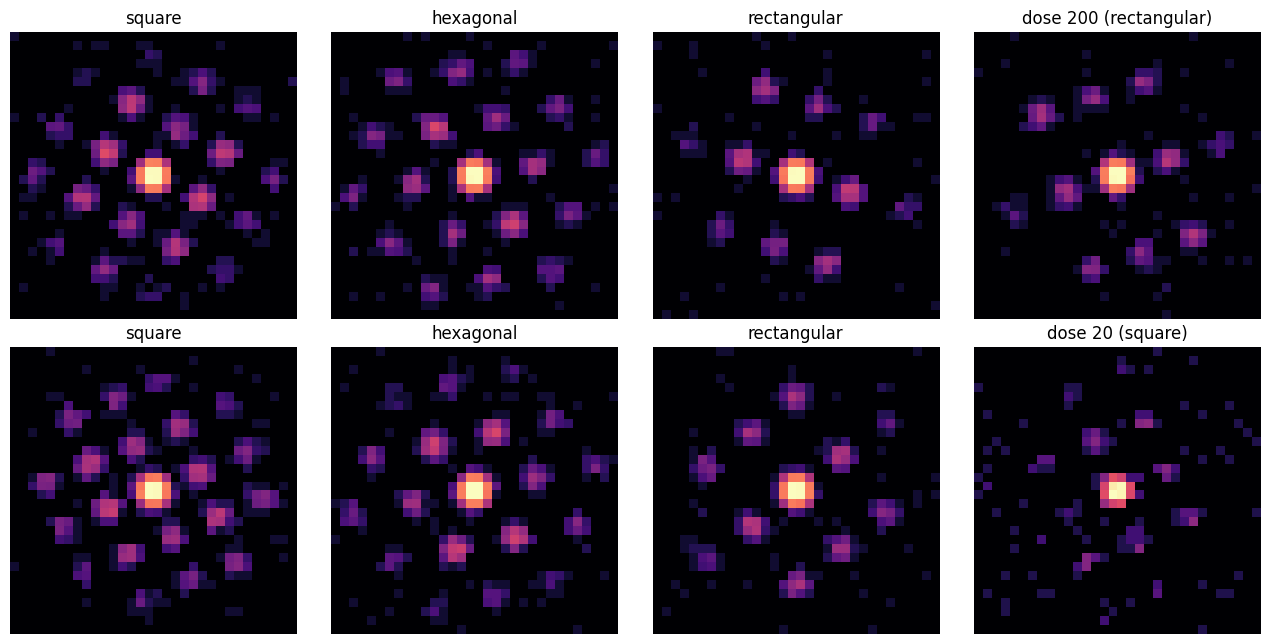

In [7]:
# --- Cell 7: look at the data ---
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for j in range(3):
    idx = np.where(ytr == j)[0][:2]
    for r in range(2):
        axes[r, j].imshow(Xtr[idx[r]], cmap="magma"); axes[r, j].set_title(LATTICES[j]); axes[r, j].axis("off")
axes[0, 3].imshow(Xte[0], cmap="magma"); axes[0, 3].set_title(f"dose 200 ({LATTICES[yte[0]]})"); axes[0, 3].axis("off")
axes[1, 3].imshow(Xlow[0], cmap="magma"); axes[1, 3].set_title(f"dose 20 ({LATTICES[ylow[0]]})"); axes[1, 3].axis("off")
plt.tight_layout(); plt.show()

### Patchify → tokens

With patch size $P=4$ a 32×32 pattern becomes an $8\times 8$ grid of patches, i.e. $L=64$ tokens of
dimension $P^2=16$. The ViT embeds each flattened patch with a linear layer, prepends a learnable `[CLS]`
token and adds a learnable **positional embedding** (one vector per slot).

Below, the attention is written out by hand (not `nn.MultiheadAttention`) so we can store and inspect the
attention matrices. `use_pos=False` removes the positional embedding — the model then sees a **bag of patches**.

In [8]:
# --- Cell 8: the mini-ViT (hand-written attention, pre-norm blocks) ---

class SelfAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.h, self.dk = heads, d // heads
        self.qkv = nn.Linear(d, 3 * d)
        self.out = nn.Linear(d, d)
        self.last_attn = None

    def forward(self, x):                              # x: (B, L, d)
        B, L, d = x.shape
        q, k, v = self.qkv(x).reshape(B, L, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        A = torch.softmax(q @ k.transpose(-2, -1) / self.dk ** 0.5, dim=-1)  # (B, h, L, L)
        self.last_attn = A.detach()
        z = (A @ v).transpose(1, 2).reshape(B, L, d)
        return self.out(z)


class Block(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = SelfAttention(d, heads)
        self.mlp = nn.Sequential(nn.Linear(d, 2 * d), nn.GELU(), nn.Linear(2 * d, d))

    def forward(self, x):
        x = x + self.attn(self.n1(x))                  # pre-norm residual
        return x + self.mlp(self.n2(x))


class MiniViT(nn.Module):
    def __init__(self, size=32, patch=4, d=48, heads=4, depth=3, n_classes=3, use_pos=True, seed=0):
        super().__init__()
        torch.manual_seed(seed)                        # reproducible initialisation
        self.patch, self.use_pos = patch, use_pos
        L = (size // patch) ** 2
        self.embed = nn.Linear(patch * patch, d)
        self.cls = nn.Parameter(torch.zeros(1, 1, d))
        self.pos = nn.Parameter(0.02 * torch.randn(1, L + 1, d))
        self.blocks = nn.ModuleList([Block(d, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, n_classes)

    def tokens(self, x):                               # (B, H, W) -> (B, L, P*P)
        p = self.patch
        B, H, W = x.shape
        return x.reshape(B, H // p, p, W // p, p).permute(0, 1, 3, 2, 4).reshape(B, -1, p * p)

    def forward(self, x):
        t = self.embed(self.tokens(x))
        t = torch.cat([self.cls.expand(len(t), -1, -1), t], dim=1)
        if self.use_pos:
            t = t + self.pos
        for blk in self.blocks:
            t = blk(t)
        return self.head(self.norm(t[:, 0]))


vit = MiniViT()
print("tokens per pattern:", vit.tokens(torch.tensor(Xtr[:1])).shape)
print("trainable parameters:", sum(p.numel() for p in vit.parameters()))

tokens per pattern: torch.Size([1, 64, 16])
trainable parameters: 61107


In [9]:
# --- Cell 9: training utilities ---

def train_vit(model, Xtr, ytr, Xte, yte, epochs=25, lr=2e-3, bs=64, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    Xtr_t, ytr_t = torch.tensor(Xtr), torch.tensor(ytr)
    hist = []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr_t))
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            loss = F.cross_entropy(model(Xtr_t[idx]), ytr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        hist.append(accuracy(model, Xte, yte))
    return hist


def accuracy(model, X, y):
    model.eval()
    return (model(torch.tensor(X)).argmax(1).numpy() == y).mean()

### Train with and without positional embedding

Both models are identical except for the positional embedding. Training takes roughly 30–60 s each on a
laptop CPU. We report accuracy on the held-out test set after every epoch.

> **Honest-validation note (Week 4):** train and test patterns come from the same simulator with independent
> random draws, so this is the *most optimistic* split imaginable. Real data would require splitting by
> specimen / scan.

with positional embedding   : test acc = 0.987  (52 s)
without positional embedding: test acc = 0.905  (49 s)


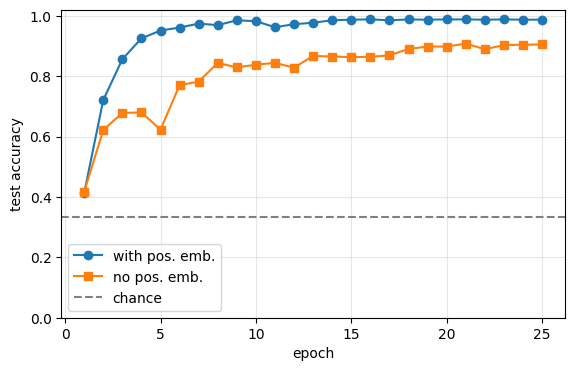

In [10]:
# --- Cell 10: train both models ---
t0 = time.time()
vit = MiniViT(use_pos=True)
hist_pos = train_vit(vit, Xtr, ytr, Xte, yte)
t1 = time.time()
vit_nopos = MiniViT(use_pos=False)
hist_nopos = train_vit(vit_nopos, Xtr, ytr, Xte, yte)
t2 = time.time()
acc_pos, acc_nopos = hist_pos[-1], hist_nopos[-1]
print(f"with positional embedding   : test acc = {acc_pos:.3f}  ({t1-t0:.0f} s)")
print(f"without positional embedding: test acc = {acc_nopos:.3f}  ({t2-t1:.0f} s)")

plt.figure(figsize=(6.5, 4))
plt.plot(range(1, len(hist_pos) + 1), hist_pos, "o-", label="with pos. emb.")
plt.plot(range(1, len(hist_nopos) + 1), hist_nopos, "s-", label="no pos. emb.")
plt.axhline(1/3, ls="--", c="grey", label="chance")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.ylim(0, 1.02); plt.legend(); plt.grid(alpha=0.3); plt.show()

**Interpretation.** Without positional embedding the model is permutation-invariant over patches. It can
still use what is *inside* each 4×4 patch (spot sizes, partial spacings, intensity statistics) — which gets
it surprisingly far — but it cannot measure angles and distances *across* the pattern. The gap between the two
curves is the value of geometry.

Let's confirm the invariance directly: shuffle the patch tokens of the no-PE model and compare logits.

In [11]:
# --- Cell 11: the no-PE ViT is invariant to patch shuffling ---
xb = torch.tensor(Xte[:8])
with torch.no_grad():
    emb = vit_nopos.embed(vit_nopos.tokens(xb))
    perm = torch.randperm(emb.shape[1])

    def run(e, model):
        z = torch.cat([model.cls.expand(len(e), -1, -1), e], 1)
        for b in model.blocks:
            z = b(z)
        return model.head(model.norm(z[:, 0]))

    d_nopos = (run(emb, vit_nopos) - run(emb[:, perm], vit_nopos)).abs().max().item()
print(f"no-PE model: max logit change under patch shuffle = {d_nopos:.1e}  (float round-off)")
with torch.no_grad():
    xs = vit.tokens(xb)[:, perm]                      # shuffle patches, then rebuild images
    p = vit.patch
    xs_img = xs.reshape(8, 8, 8, p, p).permute(0, 1, 3, 2, 4).reshape(8, 32, 32)
    agree = (vit(xb).argmax(1) == vit(xs_img).argmax(1)).float().mean().item()
print(f"with-PE model: predictions unchanged for {agree*100:.0f}% of shuffled patterns")

no-PE model: max logit change under patch shuffle = 1.4e-06  (float round-off)


with-PE model: predictions unchanged for 25% of shuffled patterns


### Dose shift

The low-dose test set was never seen in training. A model has no built-in way to tell you that an input is
out of distribution — that is the topic of Week 11.

In [12]:
# --- Cell 12: evaluate at 10x lower dose ---
acc_low = accuracy(vit, Xlow, ylow)
print(f"test accuracy at dose 200 (training dose): {acc_pos:.3f}")
print(f"test accuracy at dose 20  (never seen)   : {acc_low:.3f}")
with torch.no_grad():
    conf_low = torch.softmax(vit(torch.tensor(Xlow)), 1).max(1).values.mean().item()
    conf_hi = torch.softmax(vit(torch.tensor(Xte)), 1).max(1).values.mean().item()
print(f"mean max-softmax confidence: {conf_hi:.2f} (dose 200) vs {conf_low:.2f} (dose 20)")

test accuracy at dose 200 (training dose): 0.987
test accuracy at dose 20  (never seen)   : 0.424


mean max-softmax confidence: 0.99 (dose 200) vs 0.98 (dose 20)


**Confident and wrong.** Accuracy collapses to near chance at low dose, but the softmax confidence barely
moves. The softmax output is *not* an uncertainty estimate — Week 11 shows how to get one.

### Attention maps vs occlusion — is attention an explanation?

For each test pattern we compare two maps over the 64 patches:

- **Attention:** the `[CLS]` row of the last block's attention matrix, averaged over heads.
- **Occlusion (an intervention):** blank one 4×4 patch at a time and record the drop in the predicted class
  probability.

If attention were a faithful explanation, the two rankings should agree. We measure the **Spearman rank
correlation** per pattern.

Spearman(attention, occlusion): mean 0.04, median 0.08, fraction below 0.3: 0.83


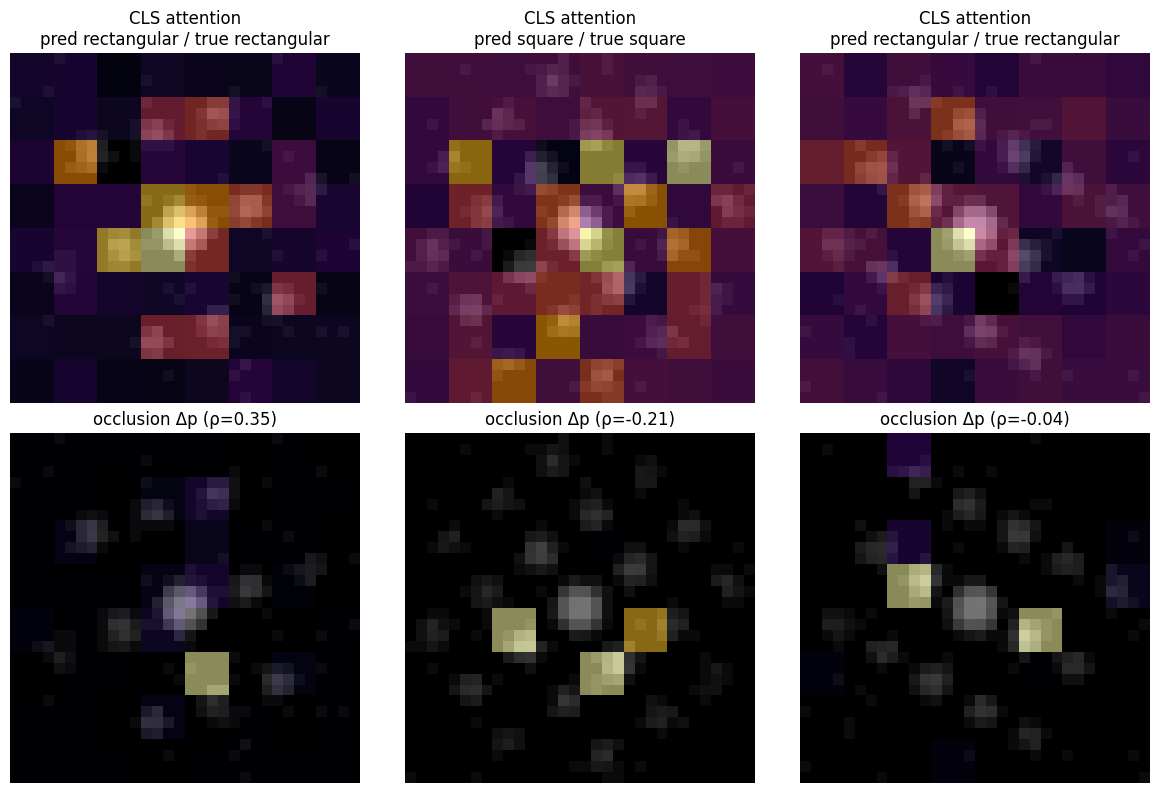

In [13]:
# --- Cell 13: attention vs occlusion on 100 test patterns ---

def ranks(v):
    return np.argsort(np.argsort(v))


@torch.no_grad()
def attention_and_occlusion(model, x):
    # x: (32, 32) numpy array -> (attention (64,), occlusion (64,), predicted class)
    model.eval()
    xt = torch.tensor(x)[None]
    logit = model(xt)
    c = logit.argmax(1).item()
    att = model.blocks[-1].attn.last_attn[0].mean(0)[0, 1:].numpy()     # CLS row, head mean, drop CLS column
    base = torch.softmax(logit, 1)[0, c].item()
    occ_batch = xt.repeat(64, 1, 1)
    for pidx in range(64):
        r, cc = divmod(pidx, 8)
        occ_batch[pidx, r*4:(r+1)*4, cc*4:(cc+1)*4] = 0.0
    occ = base - torch.softmax(model(occ_batch), 1)[:, c].numpy()
    return att, occ, c


rho = []
for idx in range(100):
    att, occ, _ = attention_and_occlusion(vit, Xte[idx])
    rho.append(np.corrcoef(ranks(att), ranks(occ))[0, 1])
rho = np.array(rho)
print(f"Spearman(attention, occlusion): mean {rho.mean():.2f}, median {np.median(rho):.2f}, "
      f"fraction below 0.3: {np.mean(rho < 0.3):.2f}")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for j in range(3):
    att, occ, c = attention_and_occlusion(vit, Xte[j])
    for r, (m, t) in enumerate([(att, "CLS attention"), (np.clip(occ, 0, None), "occlusion Δp")]):
        axes[r, j].imshow(Xte[j], cmap="gray")
        axes[r, j].imshow(np.kron(m.reshape(8, 8), np.ones((4, 4))), cmap="inferno", alpha=0.55)
        axes[r, j].set_title(f"{t}\npred {LATTICES[c]} / true {LATTICES[yte[j]]}" if r == 0 else f"{t} (ρ={rho[j]:.2f})")
        axes[r, j].axis("off")
plt.tight_layout(); plt.show()

**Interpretation.** In our run the mean rank correlation is close to **zero** (≈ 0.04). Attention spreads over the
central beam and many discs; occlusion shows that blanking almost any *single* patch changes nothing, because
the lattice is encoded redundantly by many discs — only one or two patches matter at all. Attention describes
*how information is routed* in the forward pass; occlusion measures *what the output depends on*. They answer
different questions — and neither is ground truth (blanking a patch also creates an unusual input).

Take-home: use attention maps to generate hypotheses and to spot shortcuts, then test them with an intervention.

## Exercise 2 — Patch size

**Instructions (try before running):** retrain the ViT with `patch=8` (16 tokens of 64 pixels each) for
8 epochs and compare with the `patch=4` model after the same number of epochs.

1. Which model has fewer tokens? How does the attention cost $\mathcal O(L^2)$ change?
2. With 8×8 patches, a disc and its neighbours often land *in the same* patch — what does that do to the
   role of attention vs the linear patch embedding?

The cell ships a working solution — the `# (try this yourself)` lines are the ones to attempt first.

In [14]:
# --- Cell 14: Exercise cell (working version with try-this markers) ---
EPOCHS_EX = 8
vit_p8 = MiniViT(patch=8)                                              # (try this yourself)
hist_p8 = train_vit(vit_p8, Xtr, ytr, Xte, yte, epochs=EPOCHS_EX)       # (try this yourself)
print(f"patch 8 (L=16) after {EPOCHS_EX} epochs: test acc = {hist_p8[-1]:.3f}")
print(f"patch 4 (L=64), 25-epoch schedule, at epoch {EPOCHS_EX}: test acc = {hist_pos[EPOCHS_EX-1]:.3f}")
print("attention matrix size:", 17 * 17, "vs", 65 * 65, "entries per head (incl. CLS)")

patch 8 (L=16) after 8 epochs: test acc = 0.990
patch 4 (L=64), 25-epoch schedule, at epoch 8: test acc = 0.969
attention matrix size: 289 vs 4225 entries per head (incl. CLS)


### Solution

- `patch=8` gives $L=16$ tokens (+1 CLS): the attention matrix shrinks from $65^2=4225$ to $17^2=289$ entries
  per head — a 15× saving. This is why real ViTs use 16×16 patches on 224×224 images.
- Larger patches move work from attention to the **linear patch embedding**: relations *inside* a patch are
  handled by a fixed linear map, only relations *between* patches by attention. For diffraction, discs that
  straddle a patch seam are split between two tokens — the patch grid is not aligned with the physics. That is
  the argument for disc tokens (lecture: 4D-STEM transformer case study).
- In our run the  model is actually *as good or better* after 8 epochs (≈0.99). On these small, clean
  32×32 patterns each 8×8 patch contains a whole disc plus part of its neighbourhood, so the linear embedding
  already captures local spacing, and 16 tokens are easier to learn from than 64. Do not expect this to carry
  over to real 256×256 patterns with small discs — measure it on your data.
- Note the comparison is not fully fair (different learning-rate schedules because of different epoch counts).
  A fair comparison would use the same schedule — Week 4: tune both models with the same budget.

## Part 3 — (optional) Message passing on atom-column graphs

We simulate 12×12 square lattices of atom columns (as found by a column finder, Week 5) with
**8 % substitutional** (brighter) columns and **5 % vacancies**. Each column is a **node** with feature
[intensity, 1]; columns closer than $r_c = 1.2$ lattice spacings are joined by an **edge**.

**Label:** is this a *host* column that has at least one *substitutional* neighbour?
This label cannot be decided from a column's own intensity — the information sits in the neighbours.

**Honest split:** 40 lattices ("images") for training, 20 *different* lattices for testing.
Splitting nodes randomly would leak (nodes in one image share noise and structure — Week 4).

one graph: 139 nodes, 492 directed edges, 8 substitutions, 24 positive labels


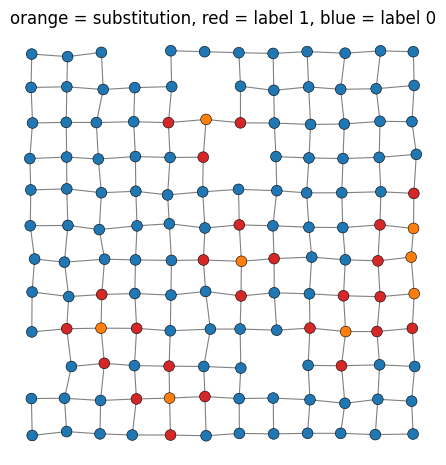

In [15]:
# --- Cell 15: graph generator ---

def atom_column_graph(rng, n=12, p_sub=0.08, p_vac=0.05, cutoff=1.2):
    """Square lattice of columns; substitutional (bright) columns and vacancies.

    Node feature: noisy column intensity. Label: host column with >=1 substitutional neighbour.
    """
    ij = np.array([(i, j) for i in range(n) for j in range(n)], float)
    keep = rng.random(len(ij)) > p_vac
    pos = ij[keep] + rng.normal(0, 0.05, (keep.sum(), 2))
    is_sub = rng.random(len(pos)) < p_sub
    inten = np.where(is_sub, 1.6, 1.0) + rng.normal(0, 0.08, len(pos))
    d = np.linalg.norm(pos[:, None] - pos[None], axis=-1)
    src, dst = np.where((d < cutoff) & (d > 0))
    nb_sub = np.zeros(len(pos), bool)
    np.logical_or.at(nb_sub, dst, is_sub[src])
    label = (~is_sub & nb_sub).astype(int)
    x = np.stack([inten, np.ones_like(inten)], 1).astype(np.float32)
    return dict(pos=pos, x=x, edges=np.stack([src, dst]), y=label, is_sub=is_sub)


rng = np.random.default_rng(1)
train_graphs = [atom_column_graph(rng) for _ in range(40)]
test_graphs = [atom_column_graph(rng) for _ in range(20)]
g = train_graphs[0]
print(f"one graph: {len(g['x'])} nodes, {g['edges'].shape[1]} directed edges, "
      f"{g['is_sub'].sum()} substitutions, {g['y'].sum()} positive labels")

(src, dst), pos = g["edges"], g["pos"]
plt.figure(figsize=(5.5, 5.5))
for a, b in zip(src, dst):
    if a < b:
        plt.plot(*pos[[a, b]].T, c="grey", lw=0.8, zorder=1)
col = np.where(g["is_sub"], "tab:orange", np.where(g["y"] == 1, "tab:red", "tab:blue"))
plt.scatter(*pos.T, c=col, s=60, zorder=2, edgecolors="k", linewidths=0.4)
plt.gca().set_aspect("equal"); plt.gca().invert_yaxis(); plt.axis("off")
plt.title("orange = substitution, red = label 1, blue = label 0"); plt.show()

### A message-passing layer in ten lines

$$\mathbf h_i' = \mathrm{ReLU}\Big(W_\text{self}\,\mathbf h_i + \sum_{j\in\mathcal N(i)} \mathrm{MLP}_\text{msg}(\mathbf h_j)\Big)$$

The edge list `edges = [src, dst]` stores one row per directed edge $j\to i$. `index_add_` sums the messages
of all edges that point to the same destination node — a **permutation-invariant** aggregation.
`TinyGNN(n_layers=0)` is the per-node MLP baseline (no neighbours at all).

In [16]:
# --- Cell 16: message passing, model, training ---

class MessagePassing(nn.Module):
    """h_i' = ReLU( W_self h_i + sum_{j in N(i)} MLP_msg(h_j) )  — sum = permutation invariant."""

    def __init__(self, d_in, d_out):
        super().__init__()
        self.self_lin = nn.Linear(d_in, d_out)
        self.msg = nn.Sequential(nn.Linear(d_in, d_out), nn.ReLU(), nn.Linear(d_out, d_out))

    def forward(self, h, edges):
        src, dst = edges
        agg = torch.zeros(h.shape[0], self.msg[-1].out_features).index_add_(0, dst, self.msg(h[src]))
        return F.relu(self.self_lin(h) + agg)


class TinyGNN(nn.Module):
    def __init__(self, d_in=2, d=16, n_layers=1):
        super().__init__()
        dims = [d_in] + [d] * n_layers
        self.layers = nn.ModuleList([MessagePassing(a, b) for a, b in zip(dims[:-1], dims[1:])])
        self.head = nn.Linear(dims[-1], 2)
        self.pre = nn.Sequential(nn.Linear(d_in, d), nn.ReLU()) if n_layers == 0 else None
        if n_layers == 0:
            self.head = nn.Linear(d, 2)

    def forward(self, x, edges):
        h = x
        if self.pre is not None:                       # 0 layers = per-node MLP baseline
            return self.head(self.pre(h))
        for layer in self.layers:
            h = layer(h, edges)
        return self.head(h)


def batch_graphs(graphs):
    xs, es, ys, off = [], [], [], 0
    for g in graphs:
        xs.append(g["x"]); es.append(g["edges"] + off); ys.append(g["y"]); off += len(g["x"])
    return torch.tensor(np.concatenate(xs)), torch.tensor(np.concatenate(es, 1)), torch.tensor(np.concatenate(ys))


def balanced_acc(pred, y):
    return 0.5 * ((pred[y == 1] == 1).float().mean() + (pred[y == 0] == 0).float().mean()).item()


def train_gnn(n_layers, train_graphs, test_graphs, epochs=300, seed=0):
    torch.manual_seed(seed)
    model = TinyGNN(n_layers=n_layers)
    xtr, etr, ytr = batch_graphs(train_graphs)
    xte, ete, yte = batch_graphs(test_graphs)
    w = torch.tensor([1.0, (ytr == 0).sum().item() / max((ytr == 1).sum().item(), 1)])
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    for _ in range(epochs):
        loss = F.cross_entropy(model(xtr, etr), ytr, weight=w)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return model, balanced_acc(model(xte, ete).argmax(1), yte)


res = {}
for n_layers in [0, 1, 2]:
    model, res[n_layers] = train_gnn(n_layers, train_graphs, test_graphs)
    print(f"{n_layers} message-passing layers: balanced accuracy on 20 unseen lattices = {res[n_layers]:.3f}")

0 message-passing layers: balanced accuracy on 20 unseen lattices = 0.551


1 message-passing layers: balanced accuracy on 20 unseen lattices = 0.991


2 message-passing layers: balanced accuracy on 20 unseen lattices = 0.999


In [17]:
# --- Cell 17: permutation equivariance of the GNN ---
model1, _ = train_gnn(1, train_graphs, test_graphs)
g = test_graphs[0]
x, e = torch.tensor(g["x"]), torch.tensor(g["edges"])
perm = torch.randperm(len(x))
inv = torch.argsort(perm)            # old index -> new index
with torch.no_grad():
    out = model1(x, e)
    out_perm = model1(x[perm], inv[e])   # relabel nodes consistently in features AND edges
gnn_equiv_err = (out_perm - out[perm]).abs().max().item()
print(f"max |f(PX, PAP^T) - P f(X, A)| = {gnn_equiv_err:.1e}")

max |f(PX, PAP^T) - P f(X, A)| = 0.0e+00


## Exercise 3 — Edge features for strain (open-ended)

The layer above ignores *where* the neighbours are. For strain, the relevant information is the
**displacement vector** $\mathbf r_j - \mathbf r_i$ on each edge.

1. Modify `atom_column_graph` so that a smooth strain field displaces the columns
   (e.g. $\mathbf r \to \mathbf r + \varepsilon\,(x - 6)\,\hat{\mathbf x}$ in half of the images) and label each
   image "strained / unstrained".
2. Pass `pos[dst] - pos[src]` as an edge feature into the message MLP (concatenate it with $\mathbf h_j$).
3. Add a **mean readout** $\mathbf h_G = \frac1N\sum_i \mathbf h_i$ and a graph-level classifier.
4. Why must you use *relative* displacements instead of absolute positions? (Hint: translation invariance.)

No solution is shipped for this one — it is a good starting point for a miniproject on atomic-resolution data.

## Self-checks

Run these asserts to confirm the key results.

In [18]:
# --- Cell 18: self-check asserts ---
Z, A = attention(Q=np.array([[1, 0], [0, 1], [1, 1], [0, 0]], float),
                 K=np.array([[1, 0], [0, 1], [1, 1], [-1, 0]], float),
                 V=np.array([[1, 0], [0, 1], [1, 1], [0, 0]], float))
assert np.allclose(A.sum(1), 1) and np.allclose(Z[2], 0.709, atol=1e-3)
print("CHECK 1 passed: attention reproduces the hand-traced example")

assert acc_pos > 0.9, f"ViT with positional embedding should exceed 0.9 (got {acc_pos:.3f})"
assert acc_pos > acc_nopos, "positional embedding should help on rotated diffraction patterns"
print(f"CHECK 2 passed: ViT {acc_pos:.3f} (with PE) > {acc_nopos:.3f} (without PE)")

assert d_nopos < 1e-4
print(f"CHECK 3 passed: no-PE ViT is permutation-invariant over patches ({d_nopos:.1e})")

assert acc_low < acc_pos - 0.2
print(f"CHECK 4 passed: dose shift hurts ({acc_pos:.3f} -> {acc_low:.3f})")

assert res[0] < 0.7 and res[1] > 0.9 and gnn_equiv_err < 1e-5
print(f"CHECK 5 passed: message passing needed (0 layers {res[0]:.2f} vs 1 layer {res[1]:.2f}); GNN equivariant")
print(f"\nTotal notebook runtime: {time.time() - T_START:.0f} s")

CHECK 1 passed: attention reproduces the hand-traced example
CHECK 2 passed: ViT 0.987 (with PE) > 0.905 (without PE)
CHECK 3 passed: no-PE ViT is permutation-invariant over patches (1.4e-06)
CHECK 4 passed: dose shift hurts (0.987 -> 0.424)
CHECK 5 passed: message passing needed (0 layers 0.55 vs 1 layer 0.99); GNN equivariant

Total notebook runtime: 120 s


## Summary

| Concept | What you did |
|---------|-------------|
| **Scaled dot-product attention** | 10 lines of NumPy; reproduced the lecture's hand-traced example |
| **Permutation equivariance** | shuffled tokens → shuffled outputs; the reason positional encodings exist |
| **$1/\sqrt{d_k}$** | without it the softmax saturates as $d_k$ grows |
| **Mini-ViT** | ~60 k parameters, 64 patch tokens, trained on a CPU to ~0.99 on rotated diffraction patterns |
| **Positional-embedding ablation** | bag of patches loses geometry (~0.90) |
| **Dose shift** | 10× lower dose → near-chance accuracy, softmax confidence still ≈ 0.98 |
| **Attention vs occlusion** | rank correlation ≈ 0 — attention ≠ explanation |
| **Message passing** | per-node model at chance, one hand-written message-passing layer ~0.99; exactly equivariant |

**Coming next (Week 11):** uncertainty, Gaussian processes & autonomous EM — models that can tell you when an
input (like the low-dose patterns above) is outside what they know.